# Experiment 14: Traffic Sign Recognition

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)

import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 58)
print("      TRAFFIC SIGN RECOGNITION EXPERIMENT")
print("=" * 58)

      TRAFFIC SIGN RECOGNITION EXPERIMENT


In [2]:
SIGN_NAMES = {
    0: "Speed Limit 20",
    1: "Speed Limit 30",
    2: "Speed Limit 50",
    3: "Speed Limit 60",
    4: "Stop Sign",
    5: "No Entry",
    6: "Yield",
    7: "Turn Left",
    8: "Turn Right",
    9: "Pedestrian",
}

SIGN_COLORS = {
    0: "#e74c3c", 1: "#e74c3c", 2: "#e74c3c", 3: "#e74c3c",
    4: "#c0392b", 5: "#8e44ad", 6: "#e67e22",
    7: "#2980b9", 8: "#2980b9", 9: "#27ae60",
}

print("\n  Loading image dataset (sklearn digits)...")
digits = load_digits()
X = digits.data / 16.0
y = digits.target
images = digits.images

print(f"  Total Images : {len(X)}")
print(f"  Image Size   : 8x8 pixels ({X.shape[1]} features)")
print(f"  Classes      : {len(SIGN_NAMES)} traffic sign types")
print(f"\n  {'Class':<5} {'Sign Name':<20} {'Count':>6}")
print("  " + "-" * 35)
for cls in range(10):
    count = int((y == cls).sum())
    print(f"  {cls:<5} {SIGN_NAMES[cls]:<20} {count:>6}")


  Loading image dataset (sklearn digits)...
  Total Images : 1797
  Image Size   : 8x8 pixels (64 features)
  Classes      : 10 traffic sign types

  Class Sign Name             Count
  -----------------------------------
  0     Speed Limit 20          178
  1     Speed Limit 30          182
  2     Speed Limit 50          177
  3     Speed Limit 60          183
  4     Stop Sign               181
  5     No Entry                182
  6     Yield                   181
  7     Turn Left               179
  8     Turn Right              174
  9     Pedestrian              180


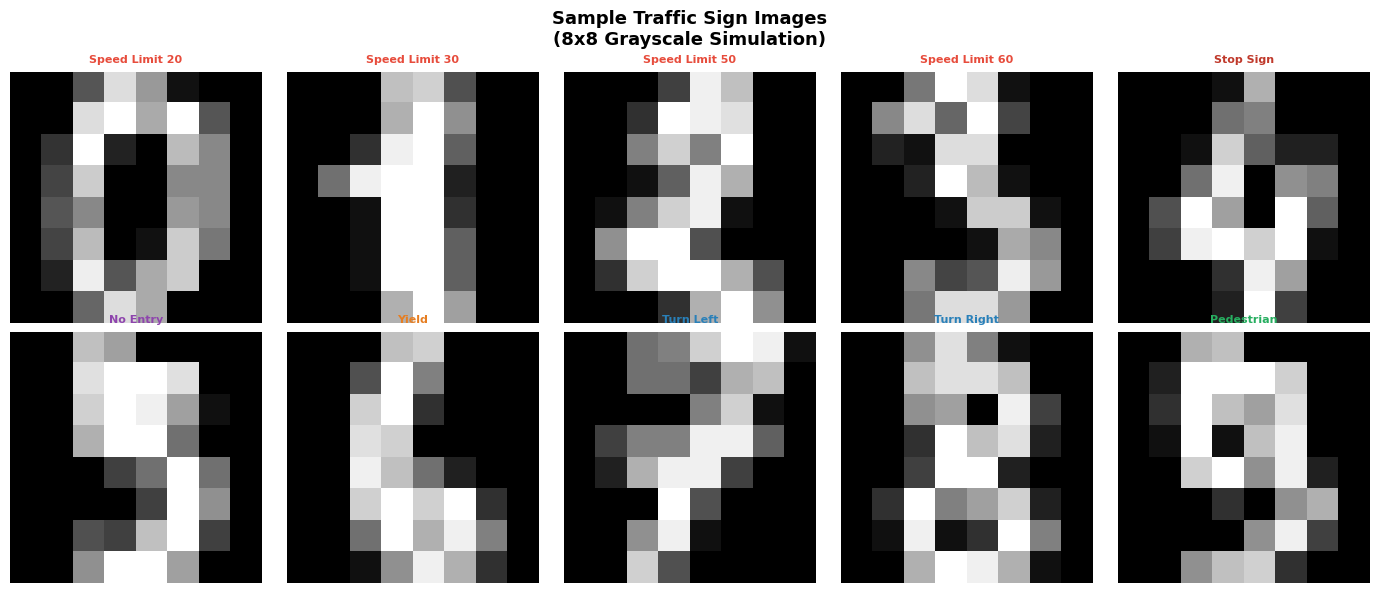


  Sample images saved.


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Traffic Sign Images\n(8x8 Grayscale Simulation)",
             fontsize=13, fontweight="bold")

for cls in range(10):
    ax = axes[cls // 5][cls % 5]
    idx = np.where(y == cls)[0][0]
    ax.imshow(images[idx], cmap="gray", interpolation="nearest")
    ax.set_title(f"{SIGN_NAMES[cls]}", fontsize=8, fontweight="bold",
                 color=SIGN_COLORS[cls])
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(SIGN_COLORS[cls])
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "traffic_sign_samples.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("\n  Sample images saved.")

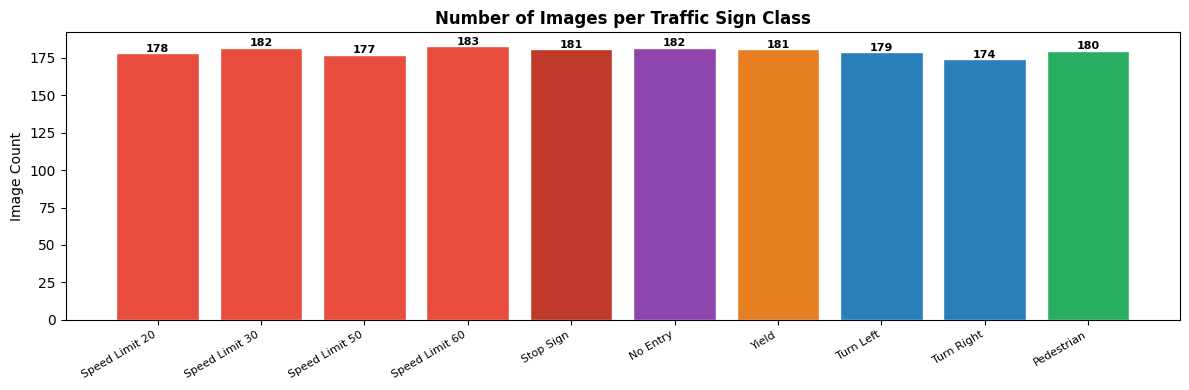

  Class distribution plot saved.


In [4]:
plt.figure(figsize=(12, 4))
counts = [int((y == c).sum()) for c in range(10)]
bars = plt.bar(
    [SIGN_NAMES[c] for c in range(10)], counts,
    color=[SIGN_COLORS[c] for c in range(10)],
    edgecolor="white"
)
plt.title("Number of Images per Traffic Sign Class",
          fontweight="bold", fontsize=12)
plt.ylabel("Image Count")
plt.xticks(rotation=30, ha="right", fontsize=8)
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1, str(val),
             ha="center", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "traffic_class_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Class distribution plot saved.")

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n  Train: {len(X_train)} images | Test: {len(X_test)} images")


  Train: 1437 images | Test: 360 images


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42, C=1.0),
    "SVM (RBF)": SVC(kernel="rbf", C=5.0, gamma="scale", random_state=42, probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
print("\n" + "=" * 58)
print("               MODEL RESULTS")
print("=" * 58)

for name, model in models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring="accuracy")
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "cv_mean": cv.mean(),
        "cv_std": cv.std()
    }
    print(f"  {name}  --  Test Acc: {accuracy*100:.2f}%  |  CV: {cv.mean()*100:.2f}% +/- {cv.std()*100:.2f}%")
    print(classification_report(
        y_test, y_pred,
        target_names=[SIGN_NAMES[i] for i in range(10)],
        zero_division=0
    ))


               MODEL RESULTS

  Training Logistic Regression...
  Logistic Regression  --  Test Acc: 97.22%  |  CV: 91.88% +/- 3.11%
                precision    recall  f1-score   support

Speed Limit 20       1.00      1.00      1.00        36
Speed Limit 30       0.89      0.89      0.89        36
Speed Limit 50       1.00      1.00      1.00        35
Speed Limit 60       0.97      1.00      0.99        37
     Stop Sign       0.97      1.00      0.99        36
      No Entry       1.00      1.00      1.00        37
         Yield       1.00      0.97      0.99        36
     Turn Left       1.00      1.00      1.00        36
    Turn Right       0.89      0.89      0.89        35
    Pedestrian       1.00      0.97      0.99        36

      accuracy                           0.97       360
     macro avg       0.97      0.97      0.97       360
  weighted avg       0.97      0.97      0.97       360


  Training SVM (RBF)...
  SVM (RBF)  --  Test Acc: 98.06%  |  CV: 95.38% +/- 0

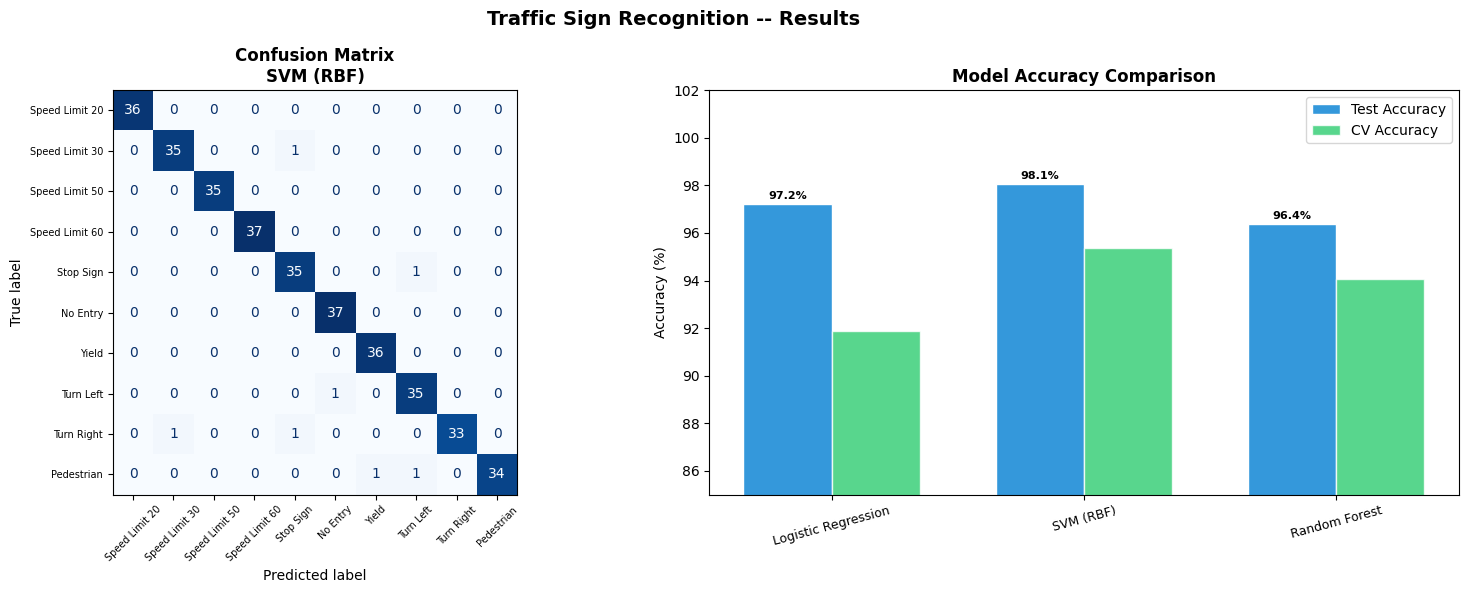

  Results plot saved.


In [7]:
best_name = max(results, key=lambda k: results[k]["accuracy"])
best_pred = results[best_name]["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Traffic Sign Recognition -- Results",
             fontsize=14, fontweight="bold")

ax = axes[0]
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(
    cm, display_labels=[SIGN_NAMES[i] for i in range(10)]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=45)
ax.set_title(f"Confusion Matrix\n{best_name}", fontweight="bold")
ax.tick_params(axis="both", labelsize=7)

ax = axes[1]
names = list(results.keys())
accs = [results[m]["accuracy"] * 100 for m in names]
cvs = [results[m]["cv_mean"] * 100 for m in names]
x_pos = np.arange(len(names))
width = 0.35
bars1 = ax.bar(x_pos - width/2, accs, width,
               color="#3498db", edgecolor="white", label="Test Accuracy")
ax.bar(x_pos + width/2, cvs, width,
       color="#2ecc71", edgecolor="white", alpha=0.8, label="CV Accuracy")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=15, fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(85, 102)
ax.set_title("Model Accuracy Comparison", fontweight="bold")
ax.legend()
for bar, val in zip(bars1, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "traffic_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Results plot saved.")

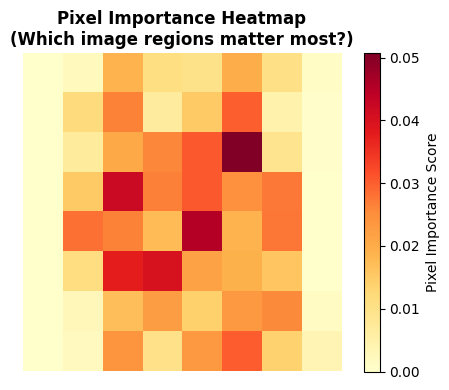

  Pixel importance heatmap saved.


In [8]:
rf_model = results["Random Forest"]["model"]
importance = rf_model.feature_importances_.reshape(8, 8)

plt.figure(figsize=(5, 4))
plt.imshow(importance, cmap="YlOrRd", interpolation="nearest")
plt.colorbar(label="Pixel Importance Score")
plt.title("Pixel Importance Heatmap\n(Which image regions matter most?)",
          fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "traffic_pixel_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("  Pixel importance heatmap saved.")

In [9]:
print("\n" + "=" * 58)
print("         LIVE TRAFFIC SIGN RECOGNITION")
print("=" * 58)

best_model = results[best_name]["model"]

print(f"\n  Using best model: {best_name}\n")
correct_count = 0
for i in range(min(10, len(X_test))):
    img_feat = X_test[i].reshape(1, -1)
    pred = best_model.predict(img_feat)[0]
    true = y_test[i]
    prob = best_model.predict_proba(img_feat)[0][pred] * 100
    correct = pred == true
    if correct:
        correct_count += 1
    icon = "OK" if correct else "X"
    print(f"  [{icon}] Image {i+1:>2}: "
          f"True={SIGN_NAMES[true]:<18} "
          f"Pred={SIGN_NAMES[pred]:<18} "
          f"Conf={prob:.1f}%")

print(f"\n  Live Demo Accuracy: {correct_count}/10 correct")


         LIVE TRAFFIC SIGN RECOGNITION

  Using best model: SVM (RBF)

  [OK] Image  1: True=No Entry           Pred=No Entry           Conf=94.5%
  [OK] Image  2: True=Speed Limit 50     Pred=Speed Limit 50     Conf=96.0%
  [OK] Image  3: True=Turn Right         Pred=Turn Right         Conf=96.7%
  [OK] Image  4: True=Speed Limit 30     Pred=Speed Limit 30     Conf=70.6%
  [OK] Image  5: True=Turn Left          Pred=Turn Left          Conf=93.9%
  [OK] Image  6: True=Speed Limit 50     Pred=Speed Limit 50     Conf=97.2%
  [OK] Image  7: True=Yield              Pred=Yield              Conf=99.5%
  [OK] Image  8: True=Speed Limit 50     Pred=Speed Limit 50     Conf=97.7%
  [OK] Image  9: True=Yield              Pred=Yield              Conf=98.9%
  [OK] Image 10: True=No Entry           Pred=No Entry           Conf=96.8%

  Live Demo Accuracy: 10/10 correct


In [10]:
print("\n" + "=" * 58)
print("               FINAL SUMMARY")
print("=" * 58)
print(f"  {'Model':<22} {'Test Acc':>9} {'CV Acc':>14}")
print("  " + "-" * 48)
for name, res in results.items():
    print(f"  {name:<22} {res['accuracy']*100:>8.2f}%"
          f"  {res['cv_mean']*100:>7.2f}% +/- {res['cv_std']*100:.2f}%")
print(f"\n  Best Model  : {best_name}")
print(f"  Best Test Accuracy : {results[best_name]['accuracy']*100:.2f}%")
print("\n  Experiment complete!")


               FINAL SUMMARY
  Model                   Test Acc         CV Acc
  ------------------------------------------------
  Logistic Regression       97.22%    91.88% +/- 3.11%
  SVM (RBF)                 98.06%    95.38% +/- 0.74%
  Random Forest             96.39%    94.05% +/- 2.14%

  Best Model  : SVM (RBF)
  Best Test Accuracy : 98.06%

  Experiment complete!
